# 1. Data Overview + Missing Values Visualization

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  9 non-null      int64  
 1   Pulse     8 non-null      float64
 2   Maxpulse  9 non-null      int64  
 3   Calories  7 non-null      float64
dtypes: float64(2), int64(2)
memory usage: 420.0 bytes
None
        Duration       Pulse    Maxpulse    Calories
count   9.000000    8.000000    9.000000    7.000000
mean   51.666667  109.875000  140.333333  339.942857
std    10.897247    5.139136   14.611639   92.344967
min    30.000000  103.000000  127.000000  195.100000
25%    45.000000  107.750000  133.000000  291.200000
50%    60.000000  109.500000  135.000000  340.000000
75%    60.000000  111.750000  145.000000  391.550000
max    60.000000  117.000000  175.000000  479.000000


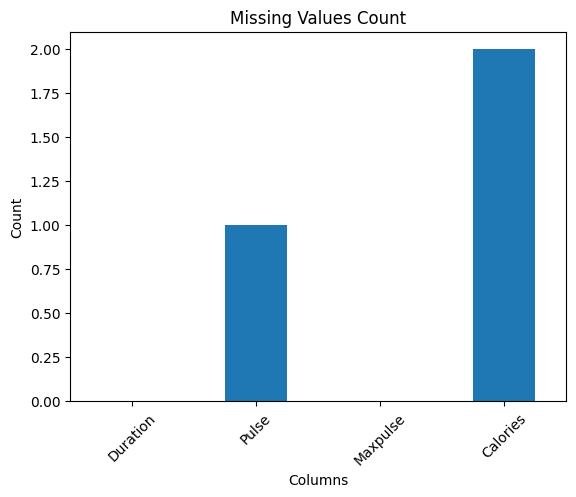

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/data.csv")

# Basic info
print(df.info())
print(df.describe())

# Missing values
missing = df.isnull().sum()

# Visualization
missing.plot(kind='bar')
plt.title("Missing Values Count")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 2. Distribution Analysis (Histogram)

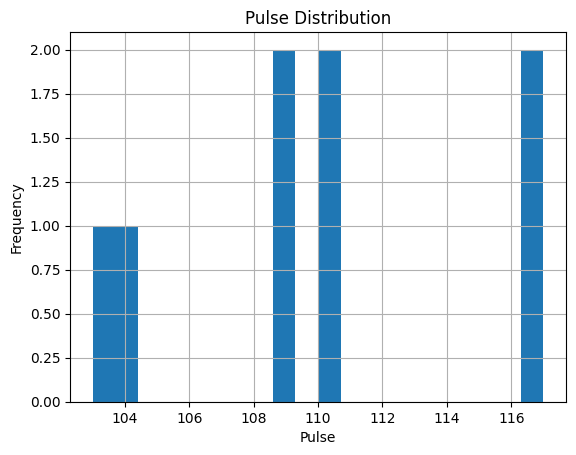

In [3]:
import matplotlib.pyplot as plt

# Example column
df['Pulse'].hist(bins=20)

plt.title("Pulse Distribution")
plt.xlabel("Pulse")
plt.ylabel("Frequency")
plt.show()

# 3. Outlier Detection (Scatter Plot)

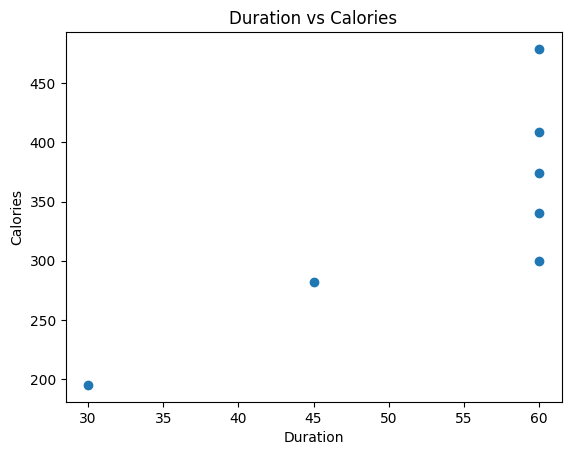

In [4]:
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()
df['Calories'] = pd.to_numeric(df['Calories'], errors='coerce')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
# Drop missing values
df = df[['Calories', 'Duration']].dropna()
# Scatter plot
plt.scatter(df['Duration'], df['Calories'])
plt.title("Duration vs Calories")
plt.xlabel("Duration")
plt.ylabel("Calories")

plt.show()

# 4.EDA

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/data.csv")

# Basic overview
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

# Statistical summary
print("\nSummary Statistics:\n", df.describe())

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Duplicate check
print("\nDuplicate Rows:", df.duplicated().sum())

# Correlation
print("\nCorrelation Matrix:\n", df.corr())

# Grouped analysis (if categorical exists)
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

for cat in cat_cols:
    for num in num_cols:
        print(f"\nAverage {num} by {cat}:\n")
        print(df.groupby(cat)[num].mean())

print("\nEDA Completed!")

Shape: (9, 4)

Data Types:
 Duration      int64
Pulse       float64
Maxpulse      int64
Calories    float64
dtype: object

First 5 rows:
    Duration  Pulse  Maxpulse  Calories
0        60  110.0       130     409.1
1        60  117.0       145     479.0
2        60  103.0       135     340.0
3        45  109.0       175     282.4
4        45  117.0       148       NaN

Summary Statistics:
         Duration       Pulse    Maxpulse    Calories
count   9.000000    8.000000    9.000000    7.000000
mean   51.666667  109.875000  140.333333  339.942857
std    10.897247    5.139136   14.611639   92.344967
min    30.000000  103.000000  127.000000  195.100000
25%    45.000000  107.750000  133.000000  291.200000
50%    60.000000  109.500000  135.000000  340.000000
75%    60.000000  111.750000  145.000000  391.550000
max    60.000000  117.000000  175.000000  479.000000

Missing Values:
 Duration    0
Pulse       1
Maxpulse    0
Calories    2
dtype: int64

Duplicate Rows: 0

Correlation Matrix:
  